# End-to-End Evaluation — results & stage-by-stage report cards

Reads the JSON reports written by `scripts/evaluate_all.py`, then rebuilds the
**pair-level detail** behind the focused one so every stage of the pipeline gets
its own classification report and confusion matrix.

§1–§2 work offline from `data/evaluations/`. **§3 recomputes from the run's
artifacts and the label file**, so it must run where the data lives (the VM) and
needs the focused report's run to still have its Parquet artifacts on disk.

Section 3 walks the pipeline in order — blocking → deterministic rules → the
Stage-4.25 gate → the Stage-4.5 matcher → clustering — and for each stage shows
how many pairs it got right and how many it got wrong.

**Two things to keep in mind while reading (see `docs/End-to-End-Evaluation-Guide.md`):**

- **Leakage.** The Stage-4.25 gate and the Stage-4.5 matcher were both trained on
  the gold labels. Read their sections only from a `strict` holdout report.
- **Each stage is scored on the pool it actually saw.** The gate never sees pairs
  the rules already auto-merged; the matcher only sees gate survivors. The
  two-class matrices are restricted accordingly; the three-class routing
  matrices are not — they cover every labeled pair, so the four of them are
  directly comparable and you can watch the population settle stage by stage.

## 0. Setup

In [1]:
import subprocess
import sys
from pathlib import Path


def _service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "data").is_dir() and (d / "src").is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")


SERVICE_ROOT = _service_root(Path.cwd())
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import settings
from src.evaluation import stage_diagnostics as sd
from src.evaluation.holdout import DEFAULT_GOLD_LABELS
from src.evaluation.report_io import (
    flow_frame,
    load_reports,
    loss_frame,
    summary_frame,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

print("service root:", SERVICE_ROOT)
print("runs dir    :", settings.runs_dir)

service root: c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
runs dir    : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\runs


### Chart styling

Three categorical hues from the validated palette, assigned to series in a fixed
sorted order so a series keeps its colour when other series appear or disappear.
Every chart is followed by its table view.

In [2]:
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua
INK, MUTED, GRID_C = "#0b0b0b", "#52514e", "#e6e5e1"


def color_map(series_names) -> dict:
    """Stable series -> colour. Keyed on the series name, never on its rank in
    the current chart, so filtering one series out never repaints the others."""
    return {name: SERIES_COLORS[i % len(SERIES_COLORS)]
            for i, name in enumerate(sorted(series_names))}


plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.edgecolor": GRID_C,
    "axes.labelcolor": MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID_C,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

## 1. (Optional) Run evaluations to add a new point

Skip this if you only want to read existing results.

`scripts/evaluate_all.py` does the whole thing in one session: pipeline over the
real data → score vs gold at **both** holdouts → pipeline over synthetic → score
vs entity truth. Gold gets both holdouts on purpose — `none` gives the tighter
clustering headline (8x more labeled positives), `strict` gives the honest
gate/matcher numbers.

Set `REUSE_REAL_RUN` to an existing `run_id` to skip re-running the real-data
pipeline, which is the slow part.

In [3]:
RUN_EVALUATIONS = False   # flip to True to add a new session
SESSION_ID = None          # e.g. "gate_v2_baseline"; None -> UTC timestamp
REUSE_REAL_RUN = None      # an existing run_id, to skip the slow real-data run

if RUN_EVALUATIONS:
    cmd = [sys.executable, "scripts/evaluate_all.py"]
    if SESSION_ID:
        cmd += ["--session-id", SESSION_ID]
    if REUSE_REAL_RUN:
        cmd += ["--reuse-real-run", REUSE_REAL_RUN]
    print("$", " ".join(str(c) for c in cmd), "\n")
    # Streamed rather than captured: the real-data pipeline run takes minutes
    # and a silent cell that long is indistinguishable from a hung one.
    proc = subprocess.run(cmd, cwd=SERVICE_ROOT)
    if proc.returncode:
        raise RuntimeError("evaluate_all.py failed — see the output above.")
else:
    print("Skipped — reading stored reports only.")

Skipped — reading stored reports only.


## 2. What results exist

In [4]:
reports = load_reports()
print(f"{len(reports)} stored report(s)\n")

summary = summary_frame(reports)
summary

27 stored report(s)



,session_id,evaluated_utc,run_id,source,holdout,labeled_pairs,positives,precision,recall,f1,TP,FP,FN,git_sha
0,20260802T225023Z,2026-08-02T22:54:36+00:00,20260802T225023Z_synthetic,synthetic,n/a,10000,2000,0.9801,0.8380,0.9035,1676,34,324,2f47aa1f
1,20260802T225023Z,2026-08-02T22:54:24+00:00,20260802T225023Z_real,gold,strict,40849,12837,0.9973,0.5417,0.7021,6954,19,5883,2f47aa1f
2,20260802T225023Z,2026-08-02T22:54:19+00:00,20260802T225023Z_real,gold,none,204805,62953,0.9923,0.5474,0.7056,34462,266,28491,2f47aa1f
3,20260802T223424Z,2026-08-02T22:38:36+00:00,20260802T223424Z_synthetic,synthetic,n/a,10000,2000,0.9801,0.8380,0.9035,1676,34,324,0662f075
4,20260802T223424Z,2026-08-02T22:38:24+00:00,20260802T223424Z_real,gold,strict,40849,12837,0.9973,0.5417,0.7021,6954,19,5883,0662f075
5,20260802T223424Z,2026-08-02T22:38:19+00:00,20260802T223424Z_real,gold,none,204805,62953,0.9923,0.5474,0.7056,34462,266,28491,0662f075
6,20260802T222718Z,2026-08-02T22:31:52+00:00,20260802T222718Z_synthetic,synthetic,n/a,10000,2000,0.9801,0.8380,0.9035,1676,34,324,0662f075
7,20260802T222718Z,2026-08-02T22:31:40+00:00,20260802T222718Z_real,gold,strict,40849,12419,0.9901,0.5559,0.7120,6904,69,5515,0662f075
8,20260802T222718Z,2026-08-02T22:31:35+00:00,20260802T222718Z_real,gold,none,204805,62537,0.9910,0.5503,0.7076,34414,314,28123,0662f075
9,20260802T222102Z,2026-08-02T22:25:16+00:00,20260802T222102Z_synthetic,synthetic,n/a,10000,2000,0.9801,0.8380,0.9035,1676,34,324,0662f075


## 3. One report in detail — a report card per stage

`FOCUS = 0` is the most recently evaluated report; change it to inspect another
row of the table above. `LABELS` must point at the label file that report was
scored against — the gold file by default.

Everything below is rebuilt from the run's own artifacts under exactly the
report's holdout, so these matrices describe the same population the stored
report's counts do.

In [5]:
FOCUS = 1
LABELS = DEFAULT_GOLD_LABELS   # point at the synthetic/silver file for those reports

reports = load_reports()
report = reports[FOCUS]

diag = sd.diagnostics_for_report(report, labels=LABELS, settings=settings)

print(f"run {report['run_id']}  |  {report['label_source']}  |  "
      f"holdout: {report['leakage']['restriction']}")
print(f"evaluated {report['evaluated_utc']}  |  pipeline git sha: {report['git_sha']}")
print(diag.header())
if report["leakage"].get("note"):
    print("\n!", report["leakage"]["note"])

run 20260802T225023Z_real  |  gold  |  holdout: strict
evaluated 2026-08-02T22:54:24+00:00  |  pipeline git sha: 2f47aa1f534344b8239efd68306efc11dfef095d
run 20260802T225023Z_real  |  gold  |  holdout: strict  |  40,849 labeled pairs (12,837 match, 6,009 ambiguous)


### 3.0 How to read the two views

Every stage below gets one or both of these.

**The two-class view** — the stage's own decision, on the pairs it actually saw,
against the target it was built to hit. The gate is scored against *plausible*
(match ∪ ambiguous), because keeping an ambiguous pair alive is correct behavior
for a filter; the matcher against *confident match*, because merging an
ambiguous pair is not what it was trained to do. Scoring either against the bare
match label reports a failure that is actually the design.

**The three-class routing view** — where each pair *should* have gone
(non-match → `no_match`, ambiguous → `human_review`, match → `auto_merge`)
versus where the pipeline had it once that stage had spoken. This one runs over
**every** labeled pair, so the diagonal is correct routing, above the diagonal is
too aggressive, and below it is too cautious.

The heatmap shades by row share (per-class recall) and prints the absolute count
in each cell — non-matches outnumber matches several to one, so a count-shaded
grid would be one dark corner and two invisible rows.

In [6]:
def plot_matrix(counts: pd.DataFrame, pct: pd.DataFrame, *, title: str,
                xlabel: str = "system decision", ylabel: str = "label"):
    """Confusion matrix -> annotated heatmap. One sequential hue, light -> dark,
    per the palette's magnitude rule; cell text flips to white on the dark end
    so every label stays legible."""
    counts = counts.drop(columns="total", errors="ignore")
    fig, ax = plt.subplots(figsize=(1.55 * len(counts.columns) + 2.6,
                                    0.75 * len(counts.index) + 1.9))
    ax.imshow(pct.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=100)

    ax.set_xticks(range(len(counts.columns)), counts.columns)
    ax.set_yticks(range(len(counts.index)), counts.index)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, color=INK, loc="left")
    ax.grid(visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(counts.shape[0]):
        for c in range(counts.shape[1]):
            share = pct.iat[r, c]
            share = 0.0 if pd.isna(share) else float(share)
            ax.text(c, r, f"{int(counts.iat[r, c]):,}\n{share:.1f}%",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if share > 55 else INK)
    plt.tight_layout()
    plt.show()


def binary_view(stage: str, title: str | None = None):
    """Confusion matrix + classification report + heatmap for one stage."""
    spec = sd.BINARY_STAGES[stage]
    cm = sd.binary_confusion(diag, stage)
    pct = sd.binary_confusion(diag, stage, normalize=True)
    display(cm)
    display(sd.binary_report(diag, stage))
    plot_matrix(cm, pct, title=title or spec.title,
                xlabel="stage decision", ylabel="label")


def routing_view(stage: str, title: str | None = None, population: str | None = None):
    """Three-class routing matrix + classification report + heatmap."""
    cm = sd.route_confusion(diag, stage, population=population)
    pct = sd.route_confusion(diag, stage, normalize=True, population=population)
    display(cm)
    display(sd.route_report(diag, stage, population=population))
    plot_matrix(cm, pct, title=title or f"Routing after {stage}",
                xlabel="system routed to", ylabel="expected route")

### 3.1 Blocking — was the pair ever considered?

Blocking is a pure filter, and the only cell that costs anything is
**true match → not blocked**: no later stage can recover a pair that was never
emitted. False positives are free by design — blocking over-generates and the
rules, the gate and the matcher exist to clean up after it, so a low precision
here is the intended shape, not a defect.

predicted,not blocked,blocked,total
actual,,,
non-match,19633,8379,28012
true match,0,12837,12837


,precision,recall,f1,support,predicted
class,,,,,
non-match,1.0000,0.7009,0.8241,28012,19633
true match,0.6051,1.0000,0.7539,12837,21216
macro avg,0.8025,0.8504,0.7890,40849,40849
weighted avg,0.8759,0.7949,0.8021,40849,40849
accuracy,NaN,NaN,0.7949,40849,40849


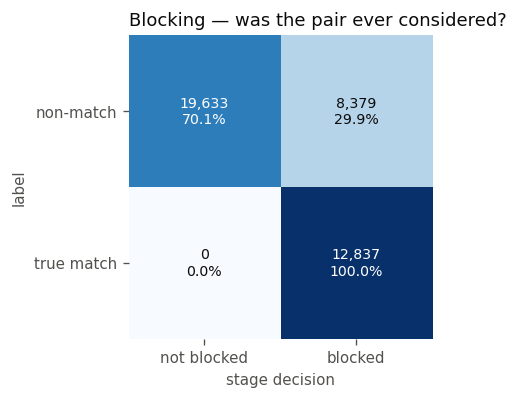

In [7]:
binary_view("blocking")

In [8]:
# The unrecoverable misses, by how much evidence the pair carried elsewhere.
missed = sd.binary_errors(diag, "blocking", kind="FN")
print(f"{len(missed):,} true pairs blocking never emitted "
      f"({len(missed) / max(int(diag.pairs['gold_match'].sum()), 1):.2%} of all true pairs)")

0 true pairs blocking never emitted (0.00% of all true pairs)


### 3.2 Deterministic rules — the three-way decision

The rules make all three calls at once: confirm and auto-merge, reject on
contradictions, or hand the pair on. So this stage is read as a three-class
matrix rather than a binary one.

The first matrix is **cumulative** — the pairs blocking never emitted are
already sitting in the `no_match` column, because that is where the pipeline has
in fact left them. The second restricts to the blocked pool, which isolates what
the rules themselves decided.

Two cells to watch: `match → no_match` (a true pair the reject rules threw away,
unrecoverable) and `non-match → auto_merge` (a wrong merge that ships, since the
rules' auto-merge tier is what clustering unions).

predicted,no_match,human_review,auto_merge,total
actual,,,,
non-match -> no_match,25344,2633,2,27979
ambiguous -> human_review,0,5998,11,6009
match -> auto_merge,0,2188,4673,6861


,precision,recall,f1,support,predicted
class,,,,,
no_match,1.0000,0.9058,0.9506,27979,25344
human_review,0.5544,0.9982,0.7129,6009,10819
auto_merge,0.9972,0.6811,0.8094,6861,4686
macro avg,0.8505,0.8617,0.8243,40849,40849
weighted avg,0.9340,0.8817,0.8919,40849,40849
accuracy,NaN,NaN,0.8817,40849,40849


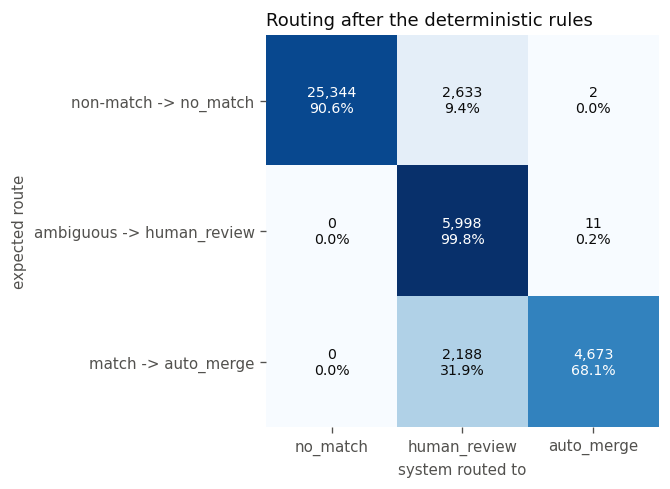

In [9]:
routing_view("rules", title="Routing after the deterministic rules")

predicted,no_match,human_review,auto_merge,total
actual,,,,
non-match -> no_match,5711,2633,2,8346
ambiguous -> human_review,0,5998,11,6009
match -> auto_merge,0,2188,4673,6861


,precision,recall,f1,support,predicted
class,,,,,
no_match,1.0000,0.6843,0.8125,8346,5711
human_review,0.5544,0.9982,0.7129,6009,10819
auto_merge,0.9972,0.6811,0.8094,6861,4686
macro avg,0.8505,0.7878,0.7783,21216,21216
weighted avg,0.8729,0.7722,0.7833,21216,21216
accuracy,NaN,NaN,0.7722,21216,21216


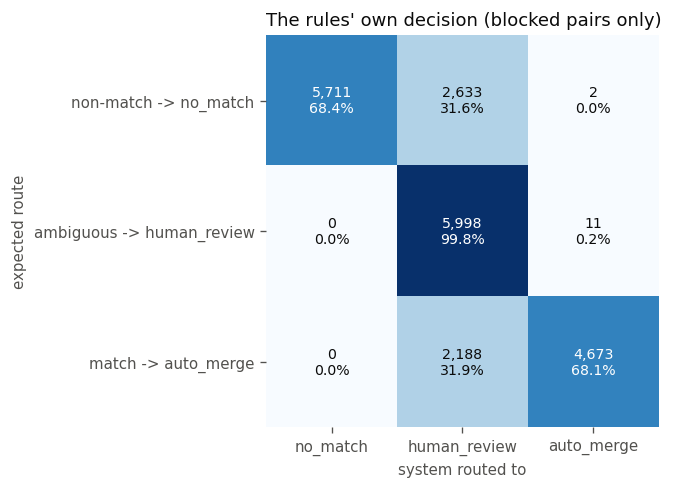

In [10]:
routing_view("rules", title="The rules' own decision (blocked pairs only)",
             population="blocked")

### 3.3 Stage-4.25 gate — the confident non-match filter

The gate scores only the rules' `non_matches` pool, and it makes one binary
call: **plausible** (pass it on) or **confident non-match** (drop it). Its drops
are unrecoverable, so recall on `plausible` is the number that matters —
precision is cheap here, because everything it passes is re-examined downstream.

predicted,dropped,passed,total
actual,,,
confident non-match,2582,51,2633
plausible,10,8176,8186


,precision,recall,f1,support,predicted
class,,,,,
confident non-match,0.9961,0.9806,0.9883,2633,2592
plausible,0.9938,0.9988,0.9963,8186,8227
macro avg,0.9950,0.9897,0.9923,10819,10819
weighted avg,0.9944,0.9944,0.9943,10819,10819
accuracy,NaN,NaN,0.9944,10819,10819


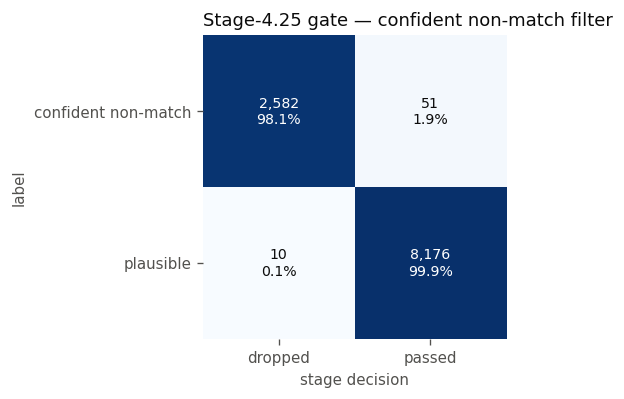

In [11]:
binary_view("gate")

#### Routing after the gate

Same three classes, now over every labeled pair. Compare it cell for cell with
§3.2: the only movement is `human_review → no_match`, since a filter can close
a pair but never merge one.

predicted,no_match,human_review,auto_merge,total
actual,,,,
non-match -> no_match,27926,51,2,27979
ambiguous -> human_review,6,5992,11,6009
match -> auto_merge,4,2184,4673,6861


,precision,recall,f1,support,predicted
class,,,,,
no_match,0.9996,0.9981,0.9989,27979,27936
human_review,0.7283,0.9972,0.8418,6009,8227
auto_merge,0.9972,0.6811,0.8094,6861,4686
macro avg,0.9084,0.8921,0.8834,40849,40849
weighted avg,0.9593,0.9447,0.9439,40849,40849
accuracy,NaN,NaN,0.9447,40849,40849


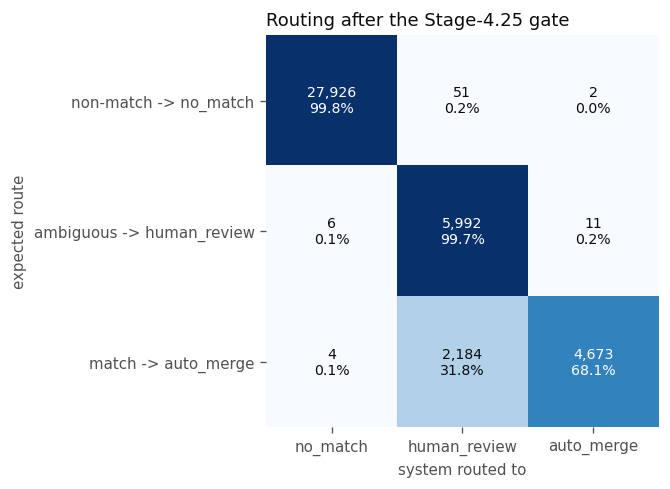

In [12]:
routing_view("gate", title="Routing after the Stage-4.25 gate")

### 3.4 Stage-4.5 matcher — the confident match classifier

The matcher sees only the gate's survivors and decides **confident match**
(`auto_merge`) or **ambiguous** (leave it in review). It has no `no_match` tier —
by construction it cannot drop a pair.

Its target is *confident match* (match and not ambiguous), so auto-merging a
pair the labeler could not resolve counts against it here even if the pair is
in fact a match. With `ml_feeds_clustering` on, that false-positive cell is a
real wrong merge in the shipped output.

predicted,left in review,auto_merge,total
actual,,,
not a confident match,6019,24,6043
confident match,323,1861,2184


,precision,recall,f1,support,predicted
class,,,,,
not a confident match,0.9491,0.9960,0.9720,6043,6342
confident match,0.9873,0.8521,0.9147,2184,1885
macro avg,0.9682,0.9241,0.9434,8227,8227
weighted avg,0.9592,0.9578,0.9568,8227,8227
accuracy,NaN,NaN,0.9578,8227,8227


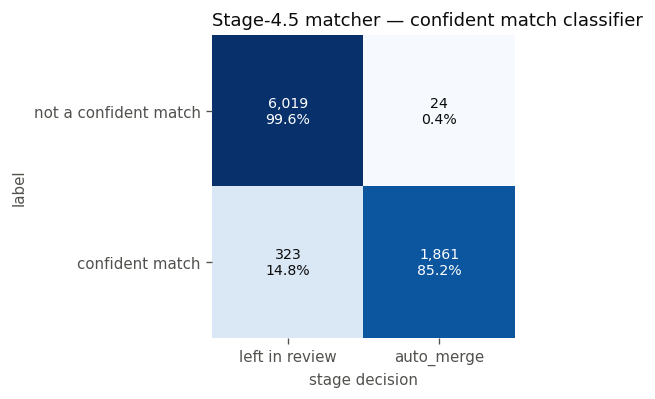

In [13]:
binary_view("ml_matcher")

#### Routing after the matcher

The first column where pairs move *toward* `auto_merge`. Everything still in
`human_review` at this point is the reviewer queue.

predicted,no_match,human_review,auto_merge,total
actual,,,,
non-match -> no_match,27926,47,6,27979
ambiguous -> human_review,6,5972,31,6009
match -> auto_merge,4,323,6534,6861


,precision,recall,f1,support,predicted
class,,,,,
no_match,0.9996,0.9981,0.9989,27979,27936
human_review,0.9417,0.9938,0.9670,6009,6342
auto_merge,0.9944,0.9523,0.9729,6861,6571
macro avg,0.9786,0.9814,0.9796,40849,40849
weighted avg,0.9902,0.9898,0.9898,40849,40849
accuracy,NaN,NaN,0.9898,40849,40849


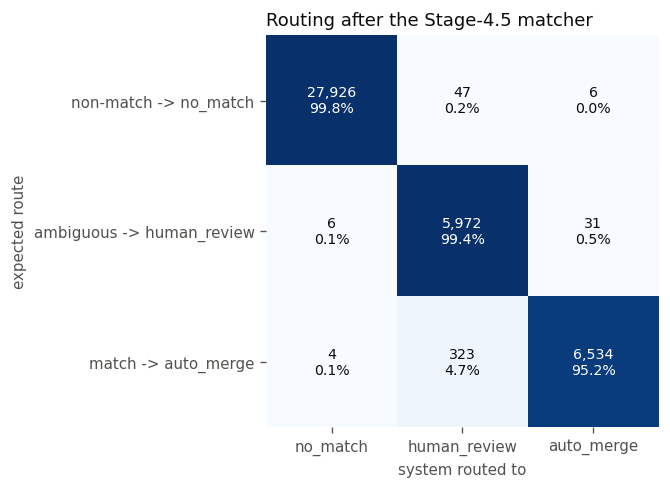

In [14]:
routing_view("ml_matcher", title="Routing after the Stage-4.5 matcher")

### 3.5 Clustering — the shipped decision

Clustering takes the connected components of the binding `auto_merge` edges, so
it can merge a pair **no classifier ever scored** — transitive closure. Those
merges are invisible to every matrix above, which is why the final numbers can
be worse than the inputs that produced them.

The two-class view is the headline: did we merge this pair or not, against the
match label.

predicted,not merged,merged,total
actual,,,
non-match,27993,19,28012
true match,5883,6954,12837


,precision,recall,f1,support,predicted
class,,,,,
non-match,0.8263,0.9993,0.9046,28012,33876
true match,0.9973,0.5417,0.7021,12837,6973
macro avg,0.9118,0.7705,0.8034,40849,40849
weighted avg,0.8801,0.8555,0.8410,40849,40849
accuracy,NaN,NaN,0.8555,40849,40849


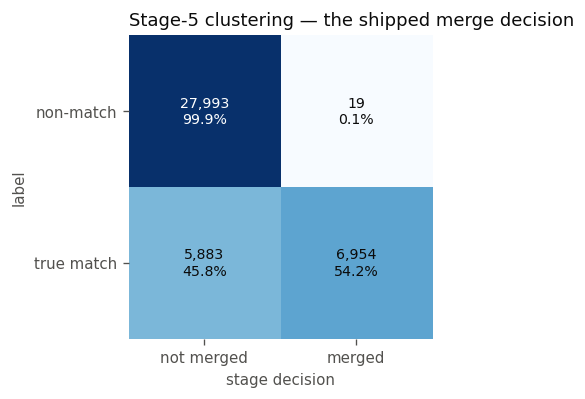

In [15]:
binary_view("clustering")

#### Final routing — the decision the pipeline actually makes

This reproduces the stored report's triage matrix. It is the fair recall view:
an ambiguous pair sitting in `human_review` is scored as **correct**, because
routing undecidable evidence to a human is exactly what the pipeline is for.

`auto_merge` recall is the share of confident matches resolved without a human.
`human_review` recall says whether genuinely undecidable pairs are reaching a
reviewer rather than being silently dropped — a low value there is the serious
failure, because a pair dropped at `no_match` is unrecoverable.

predicted,no_match,human_review,auto_merge,total
actual,,,,
non-match -> no_match,27924,46,9,27979
ambiguous -> human_review,5,5691,313,6009
match -> auto_merge,4,206,6651,6861


,precision,recall,f1,support,predicted
class,,,,,
no_match,0.9997,0.9980,0.9989,27979,27933
human_review,0.9576,0.9471,0.9523,6009,5943
auto_merge,0.9538,0.9694,0.9615,6861,6973
macro avg,0.9704,0.9715,0.9709,40849,40849
weighted avg,0.9858,0.9857,0.9857,40849,40849
accuracy,NaN,NaN,0.9857,40849,40849


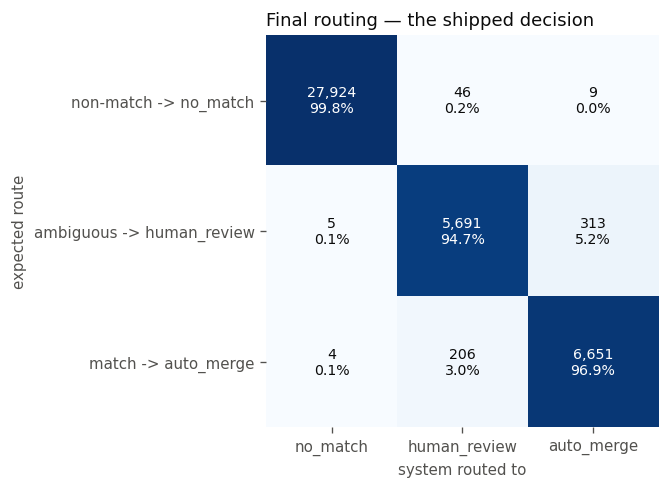

In [16]:
routing_view("clustering", title="Final routing — the shipped decision")

#### Why this matrix differs from §3.4's — transitive closure

Both matrices score the **same** labeled pairs. Only the question changes:

- **§3.4** — what did a classifier explicitly decide about this pair?
- **here** — did the two records end up in the same final cluster?

Clustering never decides a pair. `assign_clusters` takes the connected
components of the `auto_merge` edges, so it merges anything joined by a *chain*,
including pairs no classifier ever scored. The delta below is one-directional:
pairs slide **into** `auto_merge` and none slide out, because a component can
only grow.

**A worked example.** Three records, all plausibly the same patient:

| | name | DOB | SSN | phone |
|---|---|---|---|---|
| R1 | Maria Lopez | 1985-03-12 | 123-45-6789 | 555-0101 |
| R2 | Maria Lopez | 1985-03-12 | 123-45-6789 | 555-0199 |
| R3 | Maria Lopez | 1985-03-12 | *(missing)* | 555-0199 |

- `(R1, R2)` — SSN + DOB agree, so `SSN_DOB` fires → an **auto_merge** edge.
- `(R2, R3)` — name + DOB + phone agree, so `NAME_DOB_PHONE` fires → an
  **auto_merge** edge.
- `(R1, R3)` — name and DOB only; no shared SSN, no shared phone. The labeler
  marked it **ambiguous** and the matcher scored it below
  `ml_auto_merge_threshold` → **human_review**. Correct on both counts.

In §3.4, `(R1, R3)` sits on the diagonal at *ambiguous → human_review*.
Clustering then unions R1–R2 and R2–R3 into one component, so R1 and R3 share a
cluster and the pair moves to *ambiguous → auto_merge* — off the diagonal, with
no new decision taken anywhere.

**Read that cell as a question rather than as a straight error count.** The pair
label records what a human could tell from that pair *in isolation*, and the
labeler never saw R2. If R3 really is Maria, the closure is right and this
matrix is charging the pipeline for a correct merge; if R3 is her twin sister,
it is a genuine over-merge. The gold label is `ambiguous` either way, so the
matrix cannot separate the two — it is **blind** here, not pessimistic. Telling
them apart needs a truth *partition* rather than pair labels, which is what the
stored report's `cluster_level` block (B-cubed + split/merged/mixed recovery) is
for.

One movement has no benign reading: `no_match → auto_merge`. An earlier stage
explicitly filed those pairs as confident non-matches and clustering merged them
anyway, because `assign_clusters` consults neither the deterministic rules'
rejects (`data/no_match/`) nor the gate's drops (`data/gate_output/`).

In [17]:
# What moved between §3.4 and §3.5, cell for cell. Recomputed rather than
# quoted, so it stays correct when FOCUS changes.
_before = sd.route_confusion(diag, "ml_matcher").drop(columns="total", errors="ignore")
_after = sd.route_confusion(diag, "clustering").drop(columns="total", errors="ignore")

delta = _after - _before
delta.loc["net"] = delta.sum()
display(delta)

print(f"net movement into auto_merge: {int(delta.loc['net', 'auto_merge']):,} pairs\n"
      "every one of them a chain merge — the cell below counts the same pairs "
      "from the other direction")

predicted,no_match,human_review,auto_merge
actual,,,
non-match -> no_match,-2,-1,3
ambiguous -> human_review,-1,-281,282
match -> auto_merge,0,-117,117
net,-3,-399,402


net movement into auto_merge: 402 pairs
every one of them a chain merge — the cell below counts the same pairs from the other direction


In [18]:
# Merged only because of transitive closure: in the same cluster, but no stage
# ever emitted an auto_merge edge for the pair.
transitive = diag.pairs[diag.pairs["clustered"]
                        & (diag.pairs["rules_decision"] != "auto_merge")
                        & ~diag.pairs["ml_auto"]]
print(f"{len(transitive):,} labeled pairs merged by transitive closure alone — "
      f"{int((~transitive['gold_match']).sum()):,} of them labeled non-matches")

402 labeled pairs merged by transitive closure alone — 8 of them labeled non-matches


### 3.6 Where the true pairs were lost

The matrices above say how each stage did; this says which stage is responsible
for the misses. Each missed true pair is attributed to the **first** stage that
dropped it, so a pair the rules rejected is never also blamed on the gate.
Blocking and the gate are the two to watch — a pair either never blocked or
dropped by the gate is unrecoverable, while one left in review is merely slow.

These two tables come from the stored report, not from the recomputation above.

In [19]:
flow_frame(report)[['stage', 'saw', 'auto_merge', 'no_match', 'to_next', 'true_lost']]

,stage,saw,auto_merge,no_match,to_next,true_lost
0,blocking,40849,0,19633,21216,0
1,deterministic rules,21216,4686,5711,10819,0
2,non-match gate,10819,0,2592,8227,9
3,ml matcher,8227,1885,0,6342,0
4,clustering,40849,6973,0,0,0
5,-> human review queue,6342,0,0,0,0


In [20]:
losses = loss_frame(report)
losses

,stage,missed,share_pct
0,left in review (no auto_merge edge),5875,99.9
1,dropped by non-match gate,8,0.1
2,rejected by deterministic rules,0,0.0
3,not blocked,0,0.0
4,ml matcher tiered no_match,0,0.0
5,record not clustered (invalid/absent),0,0.0


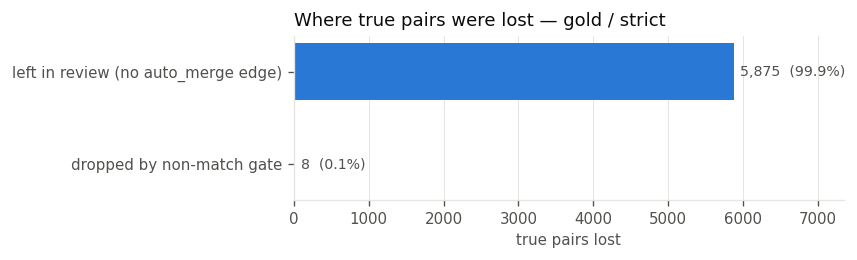

In [21]:
def plot_losses(losses: pd.DataFrame, title: str):
    """Magnitude by category -> horizontal bars, sorted. One series, so no
    legend; every bar is directly labelled instead of relying on the axis."""
    data = losses[losses["missed"] > 0]
    if data.empty:
        print("No missed true pairs to attribute.")
        return
    fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(data) + 1.4))
    y = range(len(data))
    ax.barh(list(y), data["missed"], color=SERIES_COLORS[0], height=0.62)
    ax.set_yticks(list(y), data["stage"])
    ax.invert_yaxis()
    ax.set_xlabel("true pairs lost")
    ax.set_title(title, color=INK, loc="left")
    ax.grid(axis="y", visible=False)
    span = data["missed"].max()
    for i, (n, pct) in enumerate(zip(data["missed"], data["share_pct"])):
        ax.text(n + span * 0.015, i, f"{n:,}  ({pct}%)", va="center",
                fontsize=8.5, color=MUTED)
    ax.set_xlim(0, span * 1.25)
    plt.tight_layout()
    plt.show()


plot_losses(losses, f"Where true pairs were lost — {report['label_source']} / "
                    f"{report['leakage']['restriction']}")

### 3.7 Clustering, counted by **group** instead of by pair

Everything above counts *pairs*. This section counts **groups**, which is the
question a reviewer actually asks: of the patient groups we shipped, how many are
right, and how are the wrong ones wrong?

The pair labels are lifted into truth clusters (connected components of the
positive pairs), and every truth cluster is compared to what the run produced:

| | meaning |
|---|---|
| **correct** | the group is exactly this patient's records |
| **incomplete — records missing** | some of the patient's records ended up elsewhere (under-merge) |
| **contaminated — foreign records merged in** | someone else's records are in this group (**over-merge**) |
| **both** | missing some *and* carrying strangers |

Read the **non-singleton** table. Most patients have a single record, and a
one-record group is correct by default — including them puts the headline near
1.0 and hides everything that matters.

**Caveats, in the order they bite.**

1. **Holdout fragmentation.** Truth clusters are built from whatever pairs the
   report kept. Under `holdout='strict'` that is ~20% of them, so a genuinely
   intact group comes out shattered and is counted `incomplete` even when the run
   got it right. The cell below warns when this applies — prefer the
   `holdout='none'` row of §2 here.
2. **Closure contradiction.** If the labels say A~B and B~C, the closure asserts
   A~C even where a labeler marked A~C a non-match. The count is printed below;
   when it is not near zero, treat this section as directional.
3. **Label incompleteness.** Gold is a *sample* of pairs, so a record whose true
   links were never labeled is a truth singleton, and the run correctly merging it
   is counted `contaminated`. This does not go away at `holdout='none'`. Read
   `contaminated` as an **upper bound** on over-merging. Only a declared truth
   partition (the synthetic set's `entity_id`) is free of all three.

In [22]:
from src.evaluation.cluster_eval import (
    cluster_recovery,
    induce,
    size_distribution,
    truth_clusters_from_pairs,
)

# Truth and prediction over one universe: the records this report's labels cover.
# `diag.pairs` is already restricted to the report's holdout, so the truth
# partition inherits that restriction — caveat 1 above.
truth, closure = truth_clusters_from_pairs(
    diag.pairs[["PATID_A", "PATID_B", "gold_match"]], "gold_match"
)

# Rebuild {PATID: cluster_id} from the per-pair columns. These are None for a
# record Stage 5 never covered (invalid, or absent from this run), so skip those
# rather than inventing a group for them.
pred_full: dict[str, int] = {}
for pid, cid in [*zip(diag.pairs["PATID_A"], diag.pairs["cluster_a"]),
                 *zip(diag.pairs["PATID_B"], diag.pairs["cluster_b"])]:
    if pd.notna(cid):
        pred_full[str(pid)] = int(cid)
pred = induce(pred_full, truth.keys())

print(f"universe           : {len(truth):,} records")
print(f"truth groups       : {closure.n_truth_clusters:,} "
      f"(largest {closure.max_cluster_size} records)")
print(f"groups the run made: {size_distribution(pred)['n_clusters']:,}")
print(f"closure contradicts: {closure.n_contradicted:,} labeled non-match pairs "
      f"(rate {closure.contradiction_rate})")

if report["leakage"]["restriction"] != "none":
    print(f"\n! holdout is '{report['leakage']['restriction']}' — caveat 1 applies. "
          "Truth groups are built from a sample of the pairs, so 'incomplete' "
          "below is inflated by fragmentation. Set FOCUS to the holdout='none' "
          "row of §2 for the comparable number.")

universe           : 31,695 records
truth groups       : 19,040 (largest 8 records)
groups the run made: 23,387
closure contradicts: 0 labeled non-match pairs (rate 0.0)

! holdout is 'strict' — caveat 1 applies. Truth groups are built from a sample of the pairs, so 'incomplete' below is inflated by fragmentation. Set FOCUS to the holdout='none' row of §2 for the comparable number.


In [23]:
LABELS = {
    "exact": "correct",
    "split": "incomplete — records missing",
    "merged": "contaminated — foreign records merged in",
    "mixed": "both",
}


def recovery_table(block: dict) -> pd.DataFrame:
    """cluster_recovery's four-way split, in reviewer vocabulary."""
    total = block["n_truth_clusters"]
    df = pd.DataFrame(
        [{"groups": block[k],
          "share_pct": round(100 * block[k] / total, 1) if total else None}
         for k in LABELS],
        index=list(LABELS.values()),
    )
    df.index.name = "outcome"
    df.loc["— all truth groups —"] = [total, 100.0 if total else None]
    df["groups"] = df["groups"].astype(int)   # the total row makes it float
    return df


rec = cluster_recovery(truth, pred)

print("MULTI-RECORD PATIENTS — the number that matters")
display(recovery_table(rec["non_singleton"]))

print("\nEvery truth group, including one-record patients (correct by default)")
display(recovery_table(rec))

MULTI-RECORD PATIENTS — the number that matters


,groups,share_pct
outcome,,
correct,5270,49.2
incomplete — records missing,4795,44.8
contaminated — foreign records merged in,328,3.1
both,317,3.0
— all truth groups —,10710,100.0



Every truth group, including one-record patients (correct by default)


,groups,share_pct
outcome,,
correct,11972,62.9
incomplete — records missing,4795,25.2
contaminated — foreign records merged in,1956,10.3
both,317,1.7
— all truth groups —,19040,100.0


In [24]:
# How wrong is each wrong group? A group one record short and a group welded to
# three other patients are both "incorrect", and that distinction is the whole
# difference between a nuisance and an incident.
#
# `home` = the predicted group holding most of this patient's records; anything
# of theirs outside it is missing, anything else inside it is foreign.
members_t: dict = {}
members_p: dict = {}
for r, t in truth.items():
    if r in pred:
        members_t.setdefault(t, set()).add(r)
for r, p in pred.items():
    if r in truth:
        members_p.setdefault(p, set()).add(r)

rows = []
for t, members in members_t.items():
    if len(members) < 2:          # one-record patients cannot be split
        continue
    home = max({pred[m] for m in members},
               key=lambda p: len(members_p[p] & members))
    rows.append({
        "truth_size": len(members),
        "records_missing": len(members - members_p[home]),
        "records_foreign": len(members_p[home] - members),
    })

severity = pd.DataFrame(rows)
wrong = severity[(severity["records_missing"] > 0) | (severity["records_foreign"] > 0)]
print(f"{len(wrong):,} of {len(severity):,} multi-record patients were not "
      f"reconstructed exactly\n")

if not wrong.empty:
    dist = pd.DataFrame({
        "groups missing N records": wrong["records_missing"].value_counts(),
        "groups carrying N foreign records": wrong["records_foreign"].value_counts(),
    }).fillna(0).astype(int).sort_index()
    dist.index.name = "N"
    display(dist.drop(index=0, errors="ignore"))
    display(wrong[["truth_size", "records_missing", "records_foreign"]]
            .describe().round(2))

5,440 of 10,710 multi-record patients were not reconstructed exactly



,groups missing N records,groups carrying N foreign records
N,,
1,4733,329
2,329,153
3,46,19
4,3,4
5,0,1
6,1,0


,truth_size,records_missing,records_foreign
count,5440.00,5440.00,5440.00
mean,2.24,1.02,0.13
std,0.57,0.40,0.45
min,2.00,0.00,0.00
25%,2.00,1.00,0.00
50%,2.00,1.00,0.00
75%,2.00,1.00,0.00
max,8.00,6.00,5.00


---

**The pairs behind these cells** live in `misclassified_pairs.ipynb`, which
follows the same section order and lists the actual records for every error cell
above. It is kept separate because its output is PHI.